PKL keys: dict_keys(['position', 'yaw'])
time      int64
x       float64
y       float64
yaw     float64
dtype: object
Epoch 0 | Loss: 3.873329
Epoch 10 | Loss: 2.547535
Epoch 20 | Loss: 1.501474
Epoch 30 | Loss: 0.945873
Epoch 40 | Loss: 0.709445
Epoch 50 | Loss: 0.445306
Epoch 60 | Loss: 0.248309
Epoch 70 | Loss: 0.120265
Epoch 80 | Loss: 0.064458
Epoch 90 | Loss: 0.043848


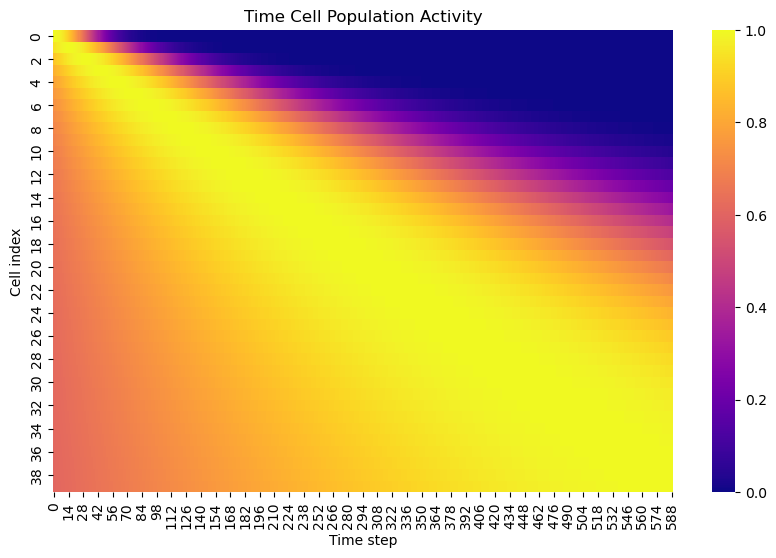

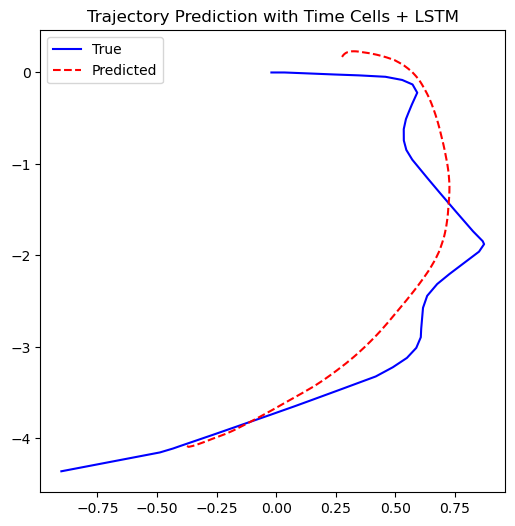

In [18]:
# ==========================================================
# Time Cell Modeling with PKL + Image Trajectory Dataset
# Author: Zhen Sun
# Description:
#   Load .pkl trajectory + image sequence
#   → Preprocess & resample
#   → Build time-cell population
#   → Train LSTM
#   → Evaluate and visualize
# ==========================================================

# --- 1. 基础依赖 ---
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
from torchvision import transforms

# --- 2. 载入轨迹数据 (.pkl) ---
def load_trajectory_from_pkl(pkl_path):
    """
    假设 pkl 存储格式为：
    {'timestamps': [...], 'x': [...], 'y': [...], 'yaw': [...]} 或类似结构
    """
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)
    
    print("PKL keys:", data.keys())

    # 提取字段
    pos = np.array(data['position'])
    yaw = np.array(data['yaw'])
    pos = pd.DataFrame(pos).astype(float).to_numpy()
    yaw = pd.DataFrame(yaw).astype(float).to_numpy().flatten()
    
    # 自动生成时间戳（假设固定采样间隔）
    t = np.arange(len(pos))


    df = pd.DataFrame({
        'time': t,
        'x': pos[:, 0],
        'y': pos[:, 1],
        'z': pos[:, 2] if pos.shape[1] > 2 else 0,
        'yaw': yaw
    })

    print(df[['time', 'x', 'y', 'yaw']].dtypes)


    # # 兼容常见字段名
    # keys = list(data.keys())
    # if 'timestamps' in keys:
    #     t = np.array(data['timestamps'])
    # elif 'time' in keys:
    #     t = np.array(data['time'])
    # else:
    #     # raise ValueError("PKL 文件中未找到时间字段")
    #     t = np.arange(len(pos))

    # x = np.array(data.get('x', data.get('pos_x', np.zeros_like(t))))
    # y = np.array(data.get('y', data.get('pos_y', np.zeros_like(t))))
    # yaw = np.array(data.get('yaw', data.get('heading', np.zeros_like(t))))

    # df = pd.DataFrame({'time': t, 'x': x, 'y': y, 'yaw': yaw})
    return df.sort_values('time')

# --- 3. 图像数据加载 ---
def load_images_from_folder(image_folder, timestamps, resize=(64, 64)):
    """
    按时间戳加载图片，并转换为 tensor
    假设图片命名为 timestamp.jpg 或 timestamp.png
    """
    transform = transforms.Compose([
        transforms.Resize(resize),
        transforms.ToTensor()
    ])

    images = []
    for ts in timestamps:
        candidates = [f"{ts}.jpg", f"{ts}.png"]
        found = None
        for c in candidates:
            p = os.path.join(image_folder, c)
            if os.path.exists(p):
                found = p
                break
        if found is not None:
            img = Image.open(found).convert('RGB')
            images.append(transform(img))
        else:
            # 若缺失图片，用全零图像填充
            images.append(torch.zeros(3, *resize))

    return torch.stack(images)  # shape: (N, 3, H, W)

# --- 4. 重采样轨迹 ---
def resample_trajectory(df, dt=0.1):
    t_min, t_max = df['time'].min(), df['time'].max()
    t_uniform = np.arange(t_min, t_max, dt)
    df_interp = pd.DataFrame({'time': t_uniform})
    df_interp['x'] = np.interp(t_uniform, df['time'], df['x'])
    df_interp['y'] = np.interp(t_uniform, df['time'], df['y'])
    df_interp['yaw'] = np.interp(t_uniform, df['time'], df['yaw'])
    return df_interp

# --- 5. 时间细胞群体编码 ---
def time_cell_population_encoding(times, n_cells=40, tau_range=(0.5, 10.0)):
    t_norm = (times - times.min()) / (times.max() - times.min())
    taus = np.linspace(tau_range[0], tau_range[1], n_cells)
    centers = np.linspace(0, 1, n_cells)
    population = np.zeros((len(times), n_cells))
    for i, c in enumerate(centers):
        population[:, i] = np.exp(-((t_norm - c)**2) / (2 * (taus[i]/tau_range[1])**2))
    return population

# --- 6. LSTM 模型 (支持视觉特征 + 时间细胞输入) ---
class TimeCellLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=2):
        super(TimeCellLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# --- 7. 训练流程 ---
def train_lstm(df, tc_pop, images=None, epochs=100, lr=1e-3):
    traj = df[['x', 'y']].values
    y = np.roll(traj, -1, axis=0)

    # 图像特征暂时用平均像素亮度代替（如要，可替换为CNN encoder）
    if images is not None:
        img_feat = images.view(images.size(0), -1).mean(dim=1).unsqueeze(1).numpy()
        X = np.hstack([traj, tc_pop, img_feat])
    else:
        X = np.hstack([traj, tc_pop])

    X = torch.tensor(X[:-1], dtype=torch.float32).unsqueeze(1)
    y = torch.tensor(y[:-1], dtype=torch.float32)

    model = TimeCellLSTM(input_dim=X.shape[2])
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        opt.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        opt.step()
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {loss.item():.6f}")
    return model

# --- 8. 可视化 ---
def visualize_time_cells(tc_pop):
    plt.figure(figsize=(10, 6))
    sns.heatmap(tc_pop.T, cmap='plasma')
    plt.title("Time Cell Population Activity")
    plt.xlabel("Time step")
    plt.ylabel("Cell index")
    plt.show()

def visualize_prediction(df, model, tc_pop, images=None):
    traj = df[['x', 'y']].values
    if images is not None:
        img_feat = images.view(images.size(0), -1).mean(dim=1).unsqueeze(1).numpy()
        X = np.hstack([traj, tc_pop, img_feat])
    else:
        X = np.hstack([traj, tc_pop])
    X = torch.tensor(X[:-1], dtype=torch.float32).unsqueeze(1)
    pred = model(X).detach().numpy()

    plt.figure(figsize=(6,6))
    plt.plot(df['x'], df['y'], 'b-', label='True')
    plt.plot(pred[:,0], pred[:,1], 'r--', label='Predicted')
    plt.legend()
    plt.title("Trajectory Prediction with Time Cells + LSTM")
    plt.show()

# --- 9. 主程序执行 ---
if __name__ == "__main__":
    # 修改路径
    # pkl_path = "data/traj.pkl"
    # img_folder = "data/images"

    pkl_path = "/media/zhen/Data/Datasets/nomad_data/go_stanford/no1vc_7_0/traj_data.pkl"
    img_folder = "/media/zhen/Data/Datasets/nomad_data/go_stanford/no1vc_7_0"

    df = load_trajectory_from_pkl(pkl_path)
    df_resampled = resample_trajectory(df)
    tc_pop = time_cell_population_encoding(df_resampled['time'].values, n_cells=40)

    # 加载图片 (可选)
    images = load_images_from_folder(img_folder, df_resampled['time'].astype(str).values)

    model = train_lstm(df_resampled, tc_pop, images, epochs=100)
    visualize_time_cells(tc_pop)
    visualize_prediction(df_resampled, model, tc_pop, images)
